In [1]:
import numpy as np
import matplotlib.pyplot as plt
from denodas_model import unet
import torch
import torch.nn as nn
print(torch.cuda.device_count())
import os
import h5py
from scipy import signal
devc = torch.device('cpu')

1


Trying Denoiser

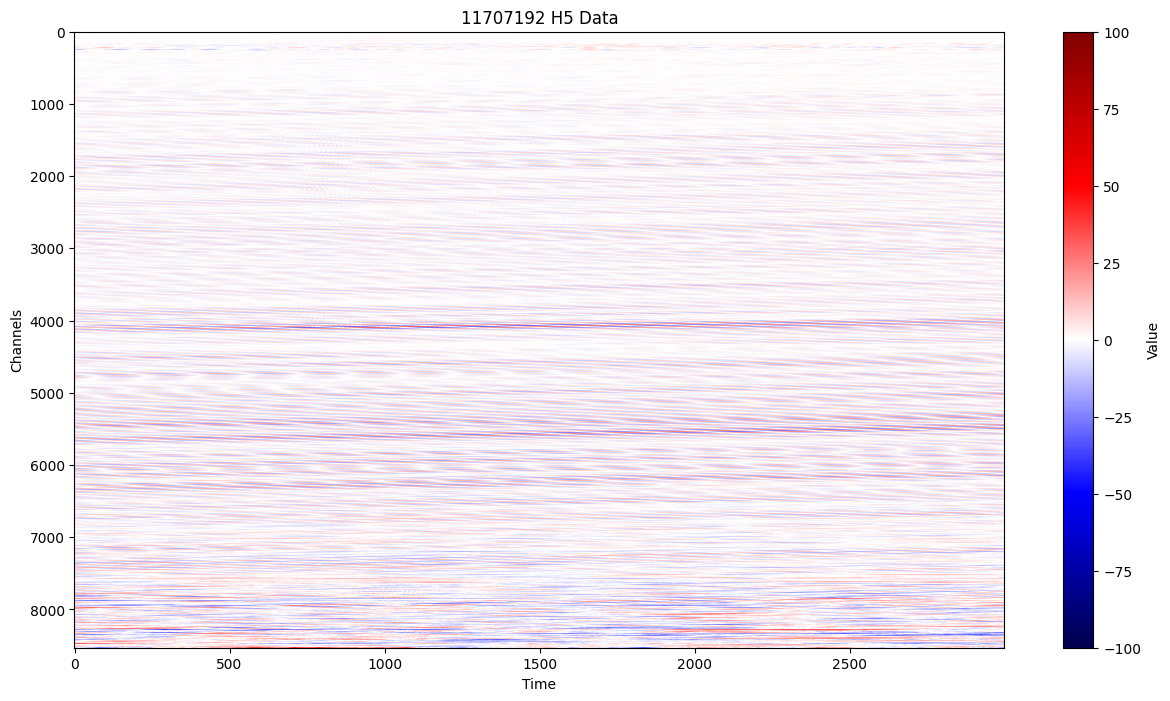

(3000, 8531)


In [2]:
# Load the .h5 file
file_path_h5 = os.path.join("raw_data", "11707192.h5")

# Load the data
with h5py.File(file_path_h5, 'r') as f:
    data_h5 = f['Acquisition/Raw[0]/RawData'][:]
    data_time_h5 = f['Acquisition/Raw[0]/RawDataTime'][:]
    data_sample_count_h5 = f['Acquisition/Raw[0]/RawDataSampleCount'][:]

    
# data_h5 = data_h5.astype(np.float64)

# Plot the data
plt.figure(figsize=(15, 8))
plt.imshow(data_h5.T, aspect='auto', cmap='seismic', vmin=-1e2, vmax=1e2)
plt.colorbar(label='Value')
plt.title("11707192 H5 Data")
plt.xlabel("Time")
plt.ylabel("Channels")
plt.show()
print(data_h5.shape)

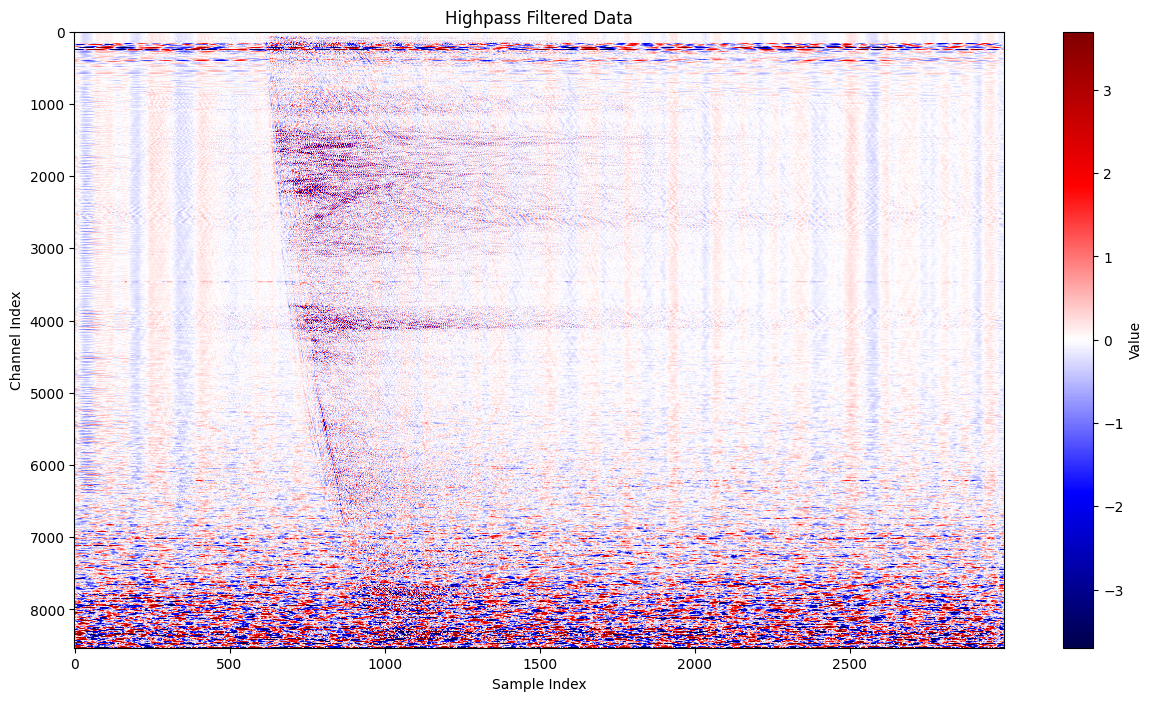

In [3]:
from scipy.signal import butter, filtfilt

# Define highpass filter
def highpass_filter(data, cutoff, fs, order=5):
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype='high', analog=False)
    y = filtfilt(b, a, data, axis=0)
    return y

# Apply highpass filter to the data
fs = 200  # Sampling frequency (Hz)
cutoff = 1  # Cutoff frequency (Hz)
filtered_data = highpass_filter(data_h5, cutoff, fs)

filtered_data_max = np.max(np.abs(filtered_data))

filtered_data_max = np.percentile(np.abs(filtered_data), 90)

# Plot the filtered data
plt.figure(figsize=(15, 8))
plt.imshow(filtered_data.T, aspect='auto', cmap='seismic', vmin=-filtered_data_max, vmax=filtered_data_max)
plt.colorbar(label='Value')
plt.title("Highpass Filtered Data")
plt.xlabel("Sample Index")
plt.ylabel("Channel Index")
plt.show()

In [4]:
print(filtered_data.shape)

data = filtered_data[:1500, 4000:5500]
data_norm = (data - np.mean(data)) / np.std(data)
data_tensor = torch.from_numpy(data_norm).to(devc)
# data_tensor = torch.tensor(data_norm, dtype=torch.float32)
print(data.shape)
print(data_norm.shape)
print(data_tensor.shape)



(3000, 8531)
(1500, 1500)
(1500, 1500)
torch.Size([1500, 1500])


In [5]:
""" Initialize the U-net model """
print(f"Using device: {devc}")
model_1 = unet(1, 16, 1024, factors=(5, 3, 2, 2), use_att=False)
# model_1 = nn.DataParallel(model_1, device_ids=[1,2,3])
model_1.to(devc)

""" Load the pretrained weights """
state_dict = torch.load('ml_models/denoiser_weights_LR08_MASK05_raw2raw_old.pt', map_location='cpu')

# Remove 'module.' prefix from keys if the model was trained with DataParallel
new_state_dict = {}
for k, v in state_dict.items():
    if k.startswith('module.'):
        new_state_dict[k[7:]] = v  # remove 'module.' prefix
    else:
        new_state_dict[k] = v
        
model_1.load_state_dict(new_state_dict)
model_1.eval()

Using device: cpu


unet(
  (relu): ReLU()
  (layer): ModuleList(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (2): MaxBlurPool2d()
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): MaxBlurPool2d()
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): MaxBlurPool2d()
    (9): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): Dropout(p=0.2, inplace=False)
    (12): MaxBlurPool2d()
    (13): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): Dropout(p=0.2, inplace=False)
    (16): Upsa

In [8]:
# Run the model on the output 4 times
num_iterations = 4
current_input = data_tensor.float()

for _ in range(num_iterations):
    current_output = model_1(current_input)
    current_input = current_output

# Convert final output back to NumPy for visualization
output_numpy = current_output.detach().numpy().squeeze()

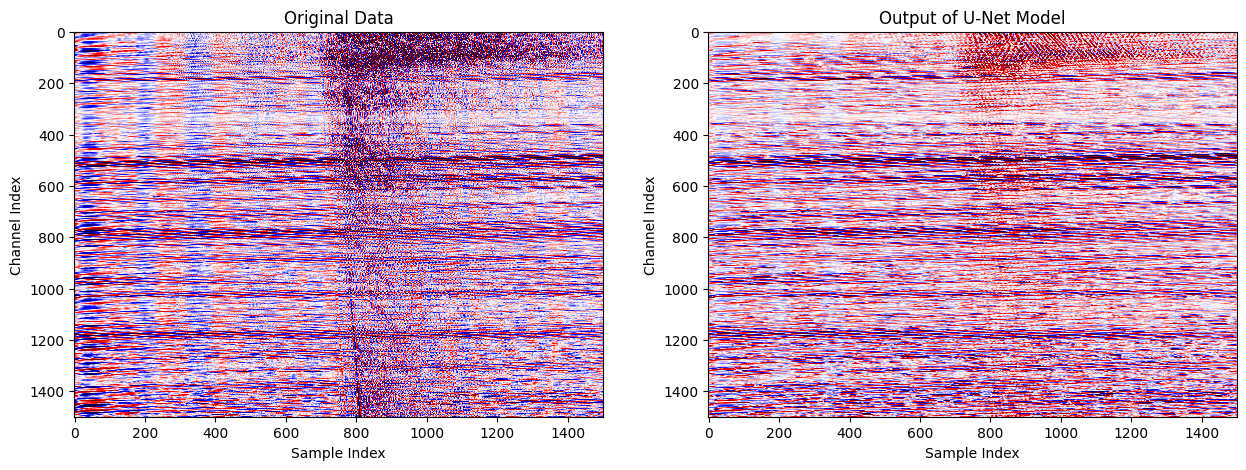

0.5247588157653809


In [9]:
fig, axs = plt.subplots(1, 2, figsize=(15, 5))
data_max = np.percentile(np.abs(data_norm), 90)
output_max =  np.percentile(np.abs(output_numpy), 90)

# Plot original data
axs[0].imshow(data_norm.T, aspect='auto', cmap='seismic', vmin=-data_max, vmax=data_max, interpolation=None)
axs[0].set_title('Original Data')
axs[0].set_xlabel('Sample Index')
axs[0].set_ylabel('Channel Index')

# Plot U-Net output
axs[1].imshow(output_numpy.T, aspect='auto', cmap='seismic', vmin=-output_max, vmax=output_max, interpolation=None)
axs[1].set_title('Output of U-Net Model')
axs[1].set_xlabel('Sample Index')
axs[1].set_ylabel('Channel Index')

plt.show()
print(output_max)

In [7]:
print(data)

[[-2.64717483e-02 -2.90314118e-02 -2.06178406e-02 ... -1.28911492e-01
   2.64129386e-01  9.87235957e-02]
 [-2.36437813e-02 -9.61112577e-03 -1.05268623e-02 ... -2.17214988e-01
  -2.99491167e-01  1.55289625e-01]
 [-1.86060246e-02 -4.56573866e-03 -5.13296256e-03 ... -4.99910878e-01
  -9.50598125e-01  4.12695249e-01]
 ...
 [-9.13126868e-03  1.19408572e-02  6.68762865e-03 ... -2.62087103e-02
   1.09955325e+00 -3.93450937e-01]
 [-4.27350448e-03  1.15790646e-02 -4.34106985e-03 ... -4.99176224e-02
   2.31577195e+00  4.21962606e-01]
 [-1.89332179e-03  1.15127757e-02 -1.31568455e-03 ... -4.59526356e-01
   2.22443561e+00  1.48000938e+00]]


SCRATCH WORK: Trying to denoise using simple FFT 

(1000,) (1000,)


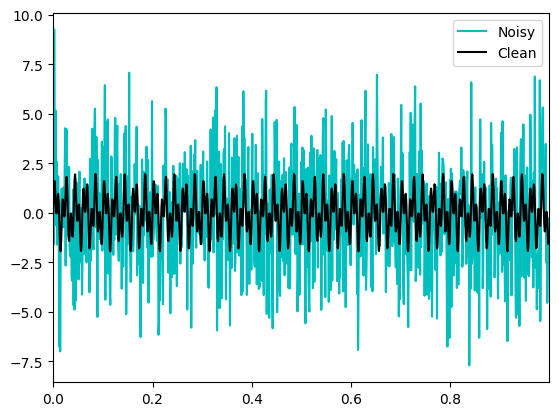

In [ ]:
# # Create a signal with two frequencies
# dt = 0.001  # Time step
# t = np.arange(0, 1, dt)  # Time vector from 0 to 1 second
# f = np.sin(2*np.pi*50*t) + np.sin(2*np.pi*120*t) # Sum of two sine waves

# # Add random white noise
# f_clean = f
# f = f + 2.5*np.random.randn(len(t))

# plt.plot(t, f, color='c', label='Noisy')
# plt.plot(t, f_clean, color='k', label='Clean')
# plt.xlim(t[0], t[-1])
# plt.legend()

/home/jupyter_share/miniconda3/envs/seismo2/lib/python3.10/site-packages/matplotlib/cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/jupyter_share/miniconda3/envs/seismo2/lib/python3.10/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


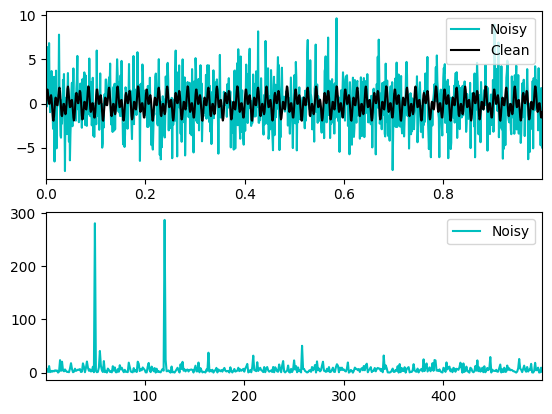

In [ ]:
# n = len(t)
# fhat = np.fft.fft(f, n)  # Compute the FFT
# PSD = fhat * np.conj(fhat) / n  # Power spectral density
# freq = (1/(dt*n)) * np.arange(n)  # Create a vector of frequencies
# L = np.arange(1, np.floor(n/2), dtype='int')  # Only plot the first half of the frequencies

# fig, axs = plt.subplots(2, 1)

# plt.sca(axs[0])
# plt.plot(t, f, color='c', label='Noisy')
# plt.plot(t, f_clean, color='k', label='Clean')
# plt.xlim(t[0], t[-1])
# plt.legend()

# plt.sca(axs[1])
# plt.plot(freq[L], PSD[L], color='c', label='Noisy')
# plt.xlim(freq[L[0]], freq[L[-1]])
# plt.legend()

In [ ]:
# # Use PSD to filter out noise
# indices = PSD > 100
# PSDclean = PSD * indices
# fhat = indices * fhat
# ffilt = np.fft.ifft(fhat)

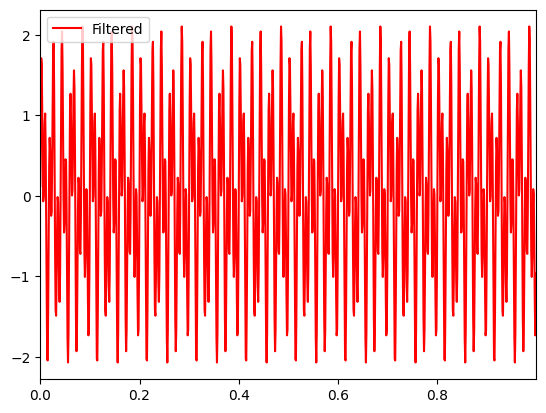

In [ ]:
# plt.plot(t, ffilt.real, color='r', label='Filtered')
# plt.xlim(t[0], t[-1])
# plt.legend()

/home/jupyter_share/miniconda3/envs/seismo2/lib/python3.10/site-packages/matplotlib/cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/jupyter_share/miniconda3/envs/seismo2/lib/python3.10/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


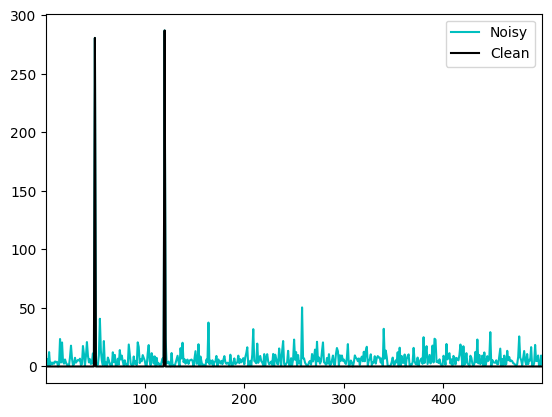

In [ ]:
# plt.plot(freq[L], PSD[L], color='c', label='Noisy')
# plt.plot(freq[L], PSDclean[L], color='k', label='Clean')
# plt.xlim(freq[L[0]], freq[L[-1]])
# plt.legend()
# plt.show()

Trying similar denoising on DAS (earthquake data)

In [ ]:
# file_path = os.path.join("raw_data", "KKFLS.h5")

# # Load the data
# f = h5py.File(file_path, 'r')

# # Get dimensions of data
# data = f['Acquisition/Raw[0]/RawData'][:] # numpy array
# data_time = f['Acquisition/Raw[0]/RawDataTime'][:]
# data_sample_count = f['Acquisition/Raw[0]/RawDataSampleCount'][:]

# print(f"Data shape: {data.shape}")
# print(f"DataTime shape: {data_time.shape}")
# print(f"DataSampleCount shape: {data_sample_count.shape}")

Data shape: (3000, 8531)
DataTime shape: (3000,)
DataSampleCount shape: (3000,)


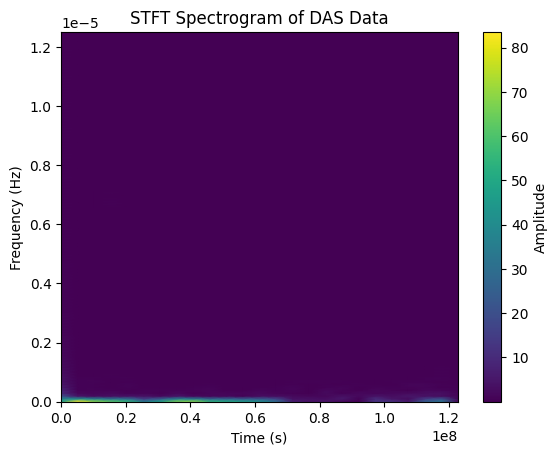

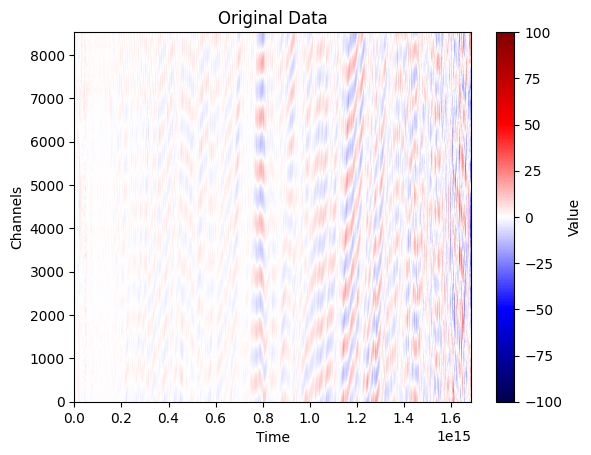

In [ ]:
# # Transpose the data to (channels, samples)
# data_transposed = data.T

# channel_number = 0

# # Choose a single channel to perform STFT (e.g., channel 0)
# channel_data = data_transposed[channel_number, :]

# # Parameters for STFT
# fs = 1 / (data_time[1] - data_time[0])  # Sampling frequency from the time vector.
# nperseg = 256
# noverlap = nperseg // 2

# # Perform STFT
# frequencies, times, Zxx = signal.stft(channel_data, fs, nperseg=nperseg, noverlap=noverlap)

# # Plot the spectrogram
# plt.pcolormesh(times, frequencies, np.abs(Zxx), shading='gouraud')
# plt.colorbar(label='Amplitude')
# plt.ylabel('Frequency (Hz)')
# plt.xlabel('Time (s)')
# plt.title('STFT Spectrogram of DAS Data')
# plt.show()

# # Plot the image as you were originally doing.
# plt.imshow(data, aspect='auto', cmap='seismic', vmin=-1e2, vmax=1e2, extent=[0, data_time[-1], 0, data.shape[1]])

# plt.xlabel("Time")
# plt.ylabel("Channels")
# plt.title("Original Data")
# plt.colorbar(label = "Value")
# plt.show()

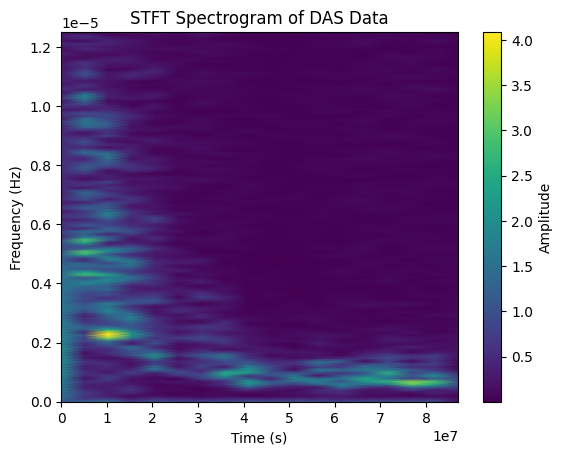

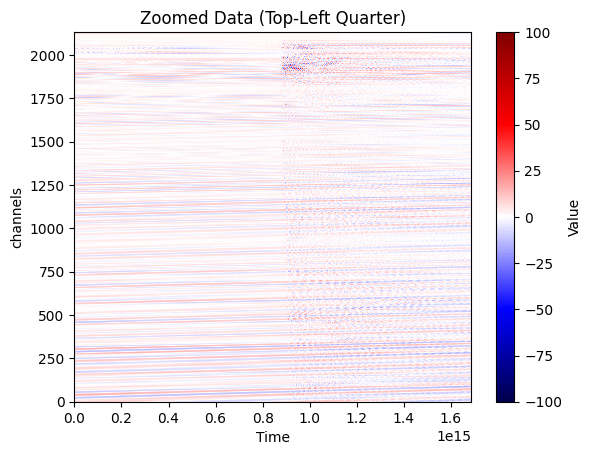

In [ ]:
# # Trying to zoom into the bottom-left corner of the data
# # Calculate midpoints
# time_midpoint = len(data_time) // 4
# channel_midpoint = data.shape[1] // 4

# # Slice the data (top-left quarter)
# zoomed_data = data[:time_midpoint, :channel_midpoint]
# zoomed_time = data_time[:time_midpoint]

# channel_number = 0

# # Choose a single channel to perform STFT (e.g., channel 0)
# channel_data = zoomed_data[channel_number, :]

# # Parameters for STFT
# fs = 1 / (zoomed_time[1] - zoomed_time[0])  # Sampling frequency from the time vector.
# nperseg = 256
# noverlap = nperseg // 2

# # Perform STFT
# frequencies, times, Zxx = signal.stft(channel_data, fs, nperseg=nperseg, noverlap=noverlap)

# # Plot the spectrogram
# plt.pcolormesh(times, frequencies, np.abs(Zxx), shading='gouraud')
# plt.colorbar(label='Amplitude')
# plt.ylabel('Frequency (Hz)')
# plt.xlabel('Time (s)')
# plt.title('STFT Spectrogram of DAS Data')
# plt.show()


# # Plot the zoomed data
# plt.imshow(zoomed_data.T, aspect='auto', cmap='seismic', vmin=-1e2, vmax=1e2, extent=[0, zoomed_time[-1], 0, channel_midpoint])

# plt.xlabel("Time")
# plt.ylabel("channels")
# plt.title("Zoomed Data (Top-Left Quarter)")
# plt.colorbar(label="Value")
# plt.show()


In [ ]:
# # Trying to filter out noise using FFT
# dt = 1/fs
# # t = np.arange(0, zoomed_time, dt)
# t = zoomed_time
# f = channel_data.copy()
# n = len(zoomed_time)
# fhat = np.fft.fft(f, n)  # Compute the FFT
# PSD = fhat * np.conj(fhat) / n  # Power spectral density
# freq = (1/(dt*n)) * np.arange(n)  # Create a vector of frequencies
# L = np.arange(1, np.floor(n/2), dtype='int')  # Only plot the first half of the frequencies

# print(t.shape)
# print(f.shape)
# print()

# # plt.figure(figsize=(12, 6))
# # plt.plot(t, f, color='k', label='Original')
# # plt.xlim(t[0], t[-1])
# # plt.xlabel("Time (s)")
# # plt.ylabel("Amplitude")
# # plt.legend()
# # plt.title(f"Channel {channel_number} (Zoomed)")
# # plt.show()

(750,)
(2132,)
2.5e-05
